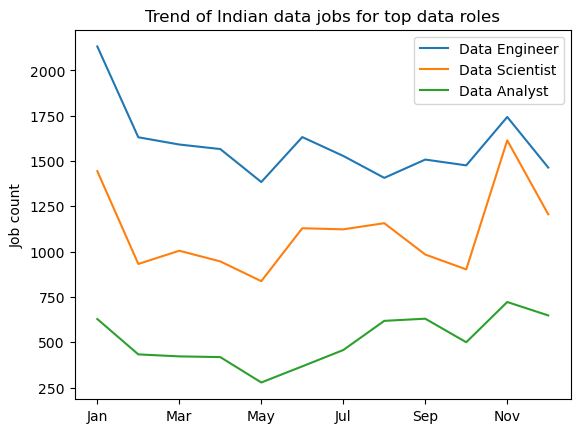

In [2]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#Filtering for only indian data jobs
df_india = df[df['job_country'] == 'India'].copy()

#Creating two new columns for job date month and month no
df_india['job_posted_month'] = df_india.job_posted_date.dt.strftime('%b')
df_india['job_posted_month_no'] = df_india.job_posted_date.dt.month

#Creating the pivot table by month as index and job titles as columns
df_india_pivot = df_india.pivot_table(index=['job_posted_month_no','job_posted_month'], columns='job_title_short', aggfunc='size')

#Sorting the table using that month no column and dropping it to assign the index to month name column
df_india_pivot = df_india_pivot.sort_index().reset_index(level=0, drop=True)

#Filtering the pivot table by top 3 job titles
top_3 = df_india.value_counts('job_title_short').head(3).index.to_list()

#Plotting
df_india_pivot[top_3].plot(kind='line')
plt.title('Trend of Indian data jobs for top data roles')
plt.xlabel('')
plt.ylabel('Job count')
plt.legend(title='')
plt.show()


In [3]:
df_india_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
Jan,175,31,628,2132,1444,70,127,448,269,192
Feb,143,35,433,1631,932,42,94,313,165,157
Mar,116,37,422,1591,1005,34,96,351,194,180
Apr,170,32,418,1566,946,54,86,375,194,169
May,103,14,278,1384,837,31,59,329,134,98
Jun,146,26,367,1632,1129,41,66,427,238,125
Jul,142,25,457,1528,1123,54,75,359,204,155
Aug,189,25,618,1407,1157,47,126,343,235,148
Sep,155,34,630,1508,984,67,85,324,195,132
